# Ablation 04 — Activation-Family Bake-off: TopK vs BatchTopK vs JumpReLU

Does the **activation function family** drive concept reproducibility, or is the
~0.004 baseline cross-seed Jaccard an artifact of TopK's hard per-sample k?

Three SAE families trained on the **same** BiomedCLIP IU X-Ray embeddings at
**matched** configuration, compared on reconstruction, dead-feature rate,
effective-L0, within-family stability, and **cross-family consensus**.

| Variant | Sparsity mechanism | Free sparsity knob |
|---|---|---|
| **TopK** | hard top-k per sample (baseline) | `k=32` |
| **BatchTopK** | global top-(k·B) across the batch → adaptive per-sample L0 | `k=32` |
| **JumpReLU** | learned per-feature threshold + straight-through estimator | `target_l0=32` |

### Pre-registered hypothesis
At matched lr, BatchTopK / JumpReLU yield **higher consensus-rate** and
**lower dead%** than TopK, because both allow features to specialize on the
samples that need them rather than forcing exactly k=32 active per sample.

### Methodological protocol (hard rules — see CLAUDE.md)
1. **Within-group Jaccard only.** Renormalize active sets to `n=20` and compute
   Jaccard within each family. Cross-family comparison uses index/size-agnostic
   metrics (signal-to-null ratio, consensus-reappearance, cross-activation
   consensus). `compute_stability` is NOT used (hardcodes `AutoEncoderTopK`).
2. **Output-dir isolation.** PathsConfig overridden to
   `models/ablation_a4/{topk,batchtopk,jumprelu}_2048/`, `results/ablation/`.
3. **No vocab rebuild** — committed `data/vocabulary.json` + `text_vocab_embeddings.pt` used as-is.
4. **Safe deserialization** — all `torch.load` via `utils.load_tensor` / `utils.load_state_dict`.
5. **Test-set discipline** — stability / Jaccard / naming / dead% on TEST only.
6. **Reproducibility** — threads + hashseed pinned before importing torch;
   ablation seeds `(0, 42, 123)`; primary_seed=42 for naming.

### Fixed parameters
- `dict_size = 2048` (shared index space across all 3 families)
- `lr = 5e-5` **pinned & matched** across all 3 families
- `steps = 12000`, seeds `(0, 42, 123)`
- `k = 32` (TopK, BatchTopK); `target_l0 = 32` (JumpReLU)
- `normalize_activations = False` (matches `SAEManager.train`)
- Naming is **gap-corrected** (`W_dec -= visual_centroid - text_centroid`).

### Baseline reference (dict_size=4096, gap-corrected)
reconstruction cosine 0.988, dead ~44%, cross-seed mean index-Jaccard 0.0038,
naming decoder<->vocab cosine mean 0.3949 / max 0.5457 (seed 42).

## 0. Setup & Configuration

In [1]:
# Reproducibility — pin threads + hashseed BEFORE importing torch.
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['PYTHONHASHSEED'] = '0'  # best-effort inside a running kernel

import sys
import json
import shutil
from pathlib import Path

import torch
import torch.nn.functional as F
import numpy as np

# Resolve project root (walk up until 'src/' exists).
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'src').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Project root: {PROJECT_ROOT}')
print(f'PyTorch:      {torch.__version__}')
print(f'Device:       {DEVICE}')

Project root: /home/marcantoniolopez/Documenti/github/xai-project-5
PyTorch:      2.12.0+cu130
Device:       cuda


In [2]:
import config
import utils

# Output-dir isolation (hard rule #2): PathsConfig is mutable, override to per-variant subdirs.
MODELS_ROOT = PROJECT_ROOT / 'models' / 'ablation_a4'   # per-variant leaves below
RESULTS_DIR = PROJECT_ROOT / 'results' / 'ablation'
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures' / 'ablation'
MODELS_ROOT.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Re-point config.paths to the isolated roots (do NOT touch baseline models/results).
config.paths.models_dir = MODELS_ROOT
config.paths.results_dir = RESULTS_DIR
config.paths.figures_dir = FIGURES_DIR

# Ablation parameters (frozen locals — never mutate the frozen SAEConfig).
DICT_SIZE = 2048          # shared index space across all 3 families
ACTIVATION_DIM = config.sae.activation_dim   # 512
LR = 5e-5                 # PINNED & MATCHED across all families (kills lr confound)
N_STEPS = 12000
BATCH_SIZE = 256
LOG_STEPS = 1000
WARMUP_STEPS = 1000
K = 32                    # TopK + BatchTopK
TARGET_L0 = 32.0          # JumpReLU
BANDWIDTH = 0.001
SPARSITY_PENALTY = 1.0
SPARSITY_WARMUP_STEPS = 2000
AUXK_ALPHA = 1.0 / 32.0
ABLATION_SEEDS = (0, 42, 123)
PRIMARY_SEED = 42

# Per-variant save roots (each variant gets its own subdir -> sae_seed{N} leaves).
VARIANT_DIRS = {
    'topk':      MODELS_ROOT / 'topk_2048',
    'batchtopk': MODELS_ROOT / 'batchtopk_2048',
    'jumprelu':  MODELS_ROOT / 'jumprelu_2048',
}
for d in VARIANT_DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

print('=== Activation Bake-off Configuration ===')
print(f'  dict_size:        {DICT_SIZE}')
print(f'  activation_dim:   {ACTIVATION_DIM}')
print(f'  lr (matched):     {LR}')
print(f'  steps:            {N_STEPS}')
print(f'  seeds:            {ABLATION_SEEDS}  (primary={PRIMARY_SEED})')
print(f'  k / target_l0:    {K} / {TARGET_L0}')
print(f'  auxk_alpha:       {AUXK_ALPHA}')
print(f'  jumprelu kwargs:  bandwidth={BANDWIDTH}, sparsity_penalty={SPARSITY_PENALTY}, sparsity_warmup={SPARSITY_WARMUP_STEPS}')
print(f'  normalize_activations: False')
print(f'  models root:      {MODELS_ROOT}')
print(f'  results dir:      {RESULTS_DIR}')
print(f'  figures dir:      {FIGURES_DIR}')

/home/marcantoniolopez/Documenti/github/xai-project-5/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== Activation Bake-off Configuration ===
  dict_size:        2048
  activation_dim:   512
  lr (matched):     5e-05
  steps:            12000
  seeds:            (0, 42, 123)  (primary=42)
  k / target_l0:    32 / 32.0
  auxk_alpha:       0.03125
  jumprelu kwargs:  bandwidth=0.001, sparsity_penalty=1.0, sparsity_warmup=2000
  normalize_activations: False
  models root:      /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a4
  results dir:      /home/marcantoniolopez/Documenti/github/xai-project-5/results/ablation
  figures dir:      /home/marcantoniolopez/Documenti/github/xai-project-5/results/figures/ablation


In [3]:
# Verify the shared inputs exist (no vocab rebuild — hard rule #3).
inputs = {
    'train_embeddings': config.paths.train_embeddings_path,
    'test_embeddings':  config.paths.test_embeddings_path,
    'vocab_embeddings': config.paths.vocab_embeddings_path,
    'vocab_labels':     config.paths.vocab_labels_path,
}
print('=== Input verification ===')
all_ok = True
for name, p in inputs.items():
    ok = p.exists()
    print(f'  [{"OK" if ok else "MISSING"}] {name:18s} -> {p}')
    all_ok &= ok
assert all_ok, 'Missing inputs — run the baseline pipeline / extract embeddings first.'

train_emb = utils.load_tensor(config.paths.train_embeddings_path)   # (5976, 512)
test_emb  = utils.load_tensor(config.paths.test_embeddings_path)    # (1494, 512)
vocab_emb = utils.load_tensor(config.paths.vocab_embeddings_path)
with open(config.paths.vocab_labels_path) as f:
    # vocabulary.json entries may be dicts or strings; normalize to term strings.
    vocab_labels = [
        e['term'] if isinstance(e, dict) else e for e in json.load(f)
    ]

print(f'\ntrain_emb: {tuple(train_emb.shape)}  test_emb: {tuple(test_emb.shape)}')
print(f'vocab_emb: {tuple(vocab_emb.shape)}  vocab_labels: {len(vocab_labels)} terms')
print(f'  train |x|_2 mean: {train_emb.norm(dim=1).mean():.4f}  (expect ~1.0, L2-normalized)')

=== Input verification ===
  [OK] train_embeddings   -> /home/marcantoniolopez/Documenti/github/xai-project-5/embeddings/standard/train_embeddings.pt
  [OK] test_embeddings    -> /home/marcantoniolopez/Documenti/github/xai-project-5/embeddings/standard/test_embeddings.pt
  [OK] vocab_embeddings   -> /home/marcantoniolopez/Documenti/github/xai-project-5/embeddings/standard/text_vocab_embeddings.pt
  [OK] vocab_labels       -> /home/marcantoniolopez/Documenti/github/xai-project-5/data/vocabulary.json

train_emb: (5955, 512)  test_emb: (1515, 512)
vocab_emb: (508, 512)  vocab_labels: 508 terms
  train |x|_2 mean: 1.0000  (expect ~1.0, L2-normalized)


## 0.1 Variant-aware library imports

We wire the three trainer/model classes through `trainSAE` directly (NOT
`SAEManager.train`, which hardcodes `TopKTrainer` and omits `auxk_alpha`).

Key library gotchas (confirmed via `inspect.signature`):
- `JumpReluTrainer` has **no `k`**, **no auto-lr**, and **`device` defaults to 'cpu'** — must pass explicitly.
- Each `trainSAE` trainer config dict must carry a `'trainer'` key (the class object).
- Final weights land at `save_dir/trainer_0/ae.pt`.

In [4]:
from dictionary_learning.trainers.top_k import AutoEncoderTopK, TopKTrainer
from dictionary_learning.trainers.batch_top_k import BatchTopKSAE, BatchTopKTrainer
from dictionary_learning.trainers.jumprelu import JumpReluTrainer
from dictionary_learning.dictionary import JumpReluAutoEncoder
from dictionary_learning.training import trainSAE

print('Trainers :', TopKTrainer.__name__, BatchTopKTrainer.__name__, JumpReluTrainer.__name__)
print('Models   :', AutoEncoderTopK.__name__, BatchTopKSAE.__name__, JumpReluAutoEncoder.__name__)
print('trainSAE :', trainSAE.__module__)

# Shared training data generator (seeded per-call for determinism).
def batch_generator(emb, batch_size, seed):
    gen = torch.Generator().manual_seed(seed)
    while True:
        perm = torch.randperm(len(emb), generator=gen)
        for i in range(0, len(perm), batch_size):
            yield emb[perm[i:i + batch_size]].to(DEVICE)

Trainers : TopKTrainer BatchTopKTrainer JumpReluTrainer
Models   : AutoEncoderTopK BatchTopKSAE JumpReluAutoEncoder
trainSAE : dictionary_learning.training


## 1. Training — three families, matched config

Each variant trains 3 seeds (`0, 42, 123`) routed through `trainSAE` with an
explicit, family-specific `trainer_cfg`. The `decay_start` is set to
`int(N_STEPS * 0.8)` to mirror `SAEManager.train`. `normalize_activations=False`
matches `SAEManager.train` (the embeddings are already L2-normalized).

**~10 min/family on GPU; hours on CPU. Do NOT run this cell unless you intend to train.**

In [5]:
DECAY_START = int(N_STEPS * 0.8)
AUTOCAST_DTYPE = torch.float32 if DEVICE in ('cpu', 'mps') else torch.bfloat16

def make_trainer_cfg(variant, seed):
    """Build the family-specific trainer_config dict for trainSAE."""
    common = {
        'activation_dim': ACTIVATION_DIM,
        'dict_size': DICT_SIZE,
        'steps': N_STEPS,
        'layer': 0,
        'lm_name': 'biomedclip',
        'lr': LR,                      # PINNED & matched
        'warmup_steps': WARMUP_STEPS,
        'decay_start': DECAY_START,
        'seed': seed,
        'device': DEVICE,
    }
    if variant == 'topk':
        cfg = {'trainer': TopKTrainer, **common, 'k': K, 'auxk_alpha': AUXK_ALPHA}
    elif variant == 'batchtopk':
        cfg = {'trainer': BatchTopKTrainer, **common, 'k': K, 'auxk_alpha': AUXK_ALPHA}
    elif variant == 'jumprelu':
        # JumpReLU: NO k; sparsity driven by target_l0. device MUST be explicit (default 'cpu').
        cfg = {
            'trainer': JumpReluTrainer, **common,
            'target_l0': TARGET_L0,
            'bandwidth': BANDWIDTH,
            'sparsity_penalty': SPARSITY_PENALTY,
            'sparsity_warmup_steps': SPARSITY_WARMUP_STEPS,
        }
    else:
        raise ValueError(variant)
    return cfg

def train_variant(variant, seeds):
    """Train all seeds for one family into its isolated subdir."""
    variant_root = VARIANT_DIRS[variant]
    for seed in seeds:
        seed_dir = variant_root / f'sae_seed{seed}'
        ae_path = seed_dir / 'trainer_0' / 'ae.pt'
        if ae_path.exists():
            print(f'  [{variant}] seed={seed} already trained -> {ae_path}')
            continue
        if seed_dir.exists():
            shutil.rmtree(seed_dir)
        print(f'  [{variant}] training seed={seed} ({N_STEPS} steps, lr={LR}, dict={DICT_SIZE}) ...')
        trainSAE(
            data=batch_generator(train_emb, BATCH_SIZE, seed=seed),
            trainer_configs=[make_trainer_cfg(variant, seed)],
            steps=N_STEPS,
            save_dir=str(seed_dir),
            save_steps=None,
            log_steps=LOG_STEPS,
            device=DEVICE,
            normalize_activations=False,   # match SAEManager.train
            verbose=True,
            autocast_dtype=AUTOCAST_DTYPE,
        )
        print(f'    done -> {ae_path}')

for v in ('topk', 'batchtopk', 'jumprelu'):
    train_variant(v, ABLATION_SEEDS)
print('\nAll variants trained.')

  [topk] training seed=0 (12000 steps, lr=5e-05, dict=2048) ...


  0%|          | 0/12000 [00:00<?, ?it/s]

  0%|          | 1/12000 [00:00<1:22:33,  2.42it/s]

Step 0: L0 = 32.0, frac_variance_explained = -0.37894749641418457


  0%|          | 9/12000 [00:00<09:06, 21.93it/s]  

...

 99%|█████████▉| 11922/12000 [00:45<00:00, 208.90it/s]

100%|█████████▉| 11949/12000 [00:46<00:00, 220.90it/s]

100%|█████████▉| 11975/12000 [00:46<00:00, 228.78it/s]

100%|██████████| 12000/12000 [00:46<00:00, 259.75it/s]

    done -> /home/marcantoniolopez/Documenti/github/xai-project-5/models/ablation_a4/jumprelu_2048/sae_seed123/trainer_0/ae.pt

All variants trained.


## 2. Bespoke loaders (family-specific)

`SAEManager.load` instantiates `AutoEncoderTopK` unconditionally and crashes on
BatchTopK/JumpReLU, so each family is loaded directly with `utils.load_state_dict`
(weights_only=True).

Decoder-row extraction differs by family:
- TopK / BatchTopK: `model.decoder.weight` is `(act_dim, dict_size)` → use `.T.clone()`.
- JumpReLU: `model.W_dec` is already `(dict_size, act_dim)` → no transpose.

In [6]:
def _ae_path(model_dir):
    """Locate ae.pt with the trainer_0 fallback that SAEManager.load uses."""
    p1 = model_dir / 'ae.pt'
    p2 = model_dir / 'trainer_0' / 'ae.pt'
    if p1.exists():
        return p1
    if p2.exists():
        return p2
    raise FileNotFoundError(f'No ae.pt under {model_dir}')

def load_model(variant, seed):
    """Load a trained model for a (variant, seed) pair. weights_only=True everywhere."""
    model_dir = VARIANT_DIRS[variant] / f'sae_seed{seed}'
    ae_path = _ae_path(model_dir)
    state = utils.load_state_dict(ae_path, device=DEVICE)   # weights_only=True
    if variant == 'topk':
        m = AutoEncoderTopK(ACTIVATION_DIM, DICT_SIZE, K)
    elif variant == 'batchtopk':
        m = BatchTopKSAE(ACTIVATION_DIM, DICT_SIZE, K)
    elif variant == 'jumprelu':
        m = JumpReluAutoEncoder(ACTIVATION_DIM, DICT_SIZE, device=DEVICE)
    else:
        raise ValueError(variant)
    m.load_state_dict(state)
    m.float().eval().to(DEVICE)
    return m

def get_decoder_rows(variant, model):
    """Return (dict_size, act_dim) decoder rows (one concept direction per row)."""
    if variant in ('topk', 'batchtopk'):
        # decoder.weight is (act_dim, dict_size) -> transpose.
        return model.decoder.weight.data.T.clone().cpu()
    elif variant == 'jumprelu':
        # W_dec is already (dict_size, act_dim).
        return model.W_dec.data.clone().cpu()
    raise ValueError(variant)

# Smoke-test one model per family.
smoke = {}
with torch.no_grad():
    for v in ('topk', 'batchtopk', 'jumprelu'):
        m = load_model(v, PRIMARY_SEED)
        x = test_emb[:64].to(DEVICE)
        x_hat = m(x)
        assert x_hat.shape == x.shape, (v, x_hat.shape)
        W = get_decoder_rows(v, m)
        assert W.shape == (DICT_SIZE, ACTIVATION_DIM), (v, W.shape)
        smoke[v] = F.cosine_similarity(x_hat, x, dim=-1).mean().item()
        del m
        if DEVICE == 'cuda':
            torch.cuda.empty_cache()
print('Smoke-test reconstruction cosine (seed 42, first 64 test samples):')
for v, c in smoke.items():
    print(f'  {v:10s}: {c:.4f}')

Smoke-test reconstruction cosine (seed 42, first 64 test samples):
  topk      : 0.9912
  batchtopk : 0.9920
  jumprelu  : 0.9907


## 3. Per-variant metrics: reconstruction, dead%, effective L0

**Dead%** is the activation-based definition (fraction of features never nonzero
across the test set), computed standalone. We never read the trainers' internal
`dead_features` counter (its `10_000_000` threshold makes JumpReLU falsely report 0%).

Effective L0 differs by family: TopK = exactly `k=32`; BatchTopK = threshold-gated
at inference; JumpReLU = count of nonzero activations above the learned threshold.

In [7]:
CHUNK = 512

def encode_sparse(variant, model, x):
    """Return the sparse [N, dict_size] activation tensor for each family."""
    outs = []
    with torch.no_grad():
        for i in range(0, len(x), CHUNK):
            xb = x[i:i + CHUNK].to(DEVICE)
            if variant == 'topk':
                outs.append(model.encode(xb, use_threshold=False).cpu())
            elif variant == 'batchtopk':
                # Inference: apply learned threshold (not the training-time global batch-top-k).
                outs.append(model.encode(xb, use_threshold=True).cpu())
            elif variant == 'jumprelu':
                outs.append(model.encode(xb).cpu())
    return torch.cat(outs, dim=0)

def reconstruct(variant, model, x):
    """x_hat via full forward (encode+decode). Mirrors SAEManager.compute_cosine_reconstruction."""
    hats = []
    with torch.no_grad():
        for i in range(0, len(x), CHUNK):
            xb = x[i:i + CHUNK].to(DEVICE)
            hats.append(model(xb).cpu())
    return torch.cat(hats, dim=0)

def recon_cos(x_hat, x):
    return F.cosine_similarity(x_hat, x, dim=-1).mean().item()

per_variant_metrics = {}
for v in ('topk', 'batchtopk', 'jumprelu'):
    seeds_metrics = {}
    for seed in ABLATION_SEEDS:
        m = load_model(v, seed)
        sparse = encode_sparse(v, m, test_emb)          # (N, dict_size)
        x_hat = reconstruct(v, m, test_emb)

        active_per_feature = (sparse != 0).float().sum(dim=0)   # (dict_size,)
        n_dead = int((active_per_feature == 0).sum().item())
        dead_pct = 100.0 * n_dead / sparse.shape[1]
        l0_per_sample = (sparse != 0).float().sum(dim=1)        # (N,)
        # activation entropy (frequency-based, matches compute_sparsity_metrics)
        freq = active_per_feature / (active_per_feature.sum() + 1e-8)
        freq_nz = freq[freq > 0]
        entropy = (-(freq_nz * freq_nz.log())).sum().item() if freq_nz.numel() else 0.0

        seeds_metrics[seed] = {
            'recon_cos':   recon_cos(x_hat, test_emb),
            'mse':         ((x_hat - test_emb) ** 2).mean().item(),
            'l0_mean':     float(l0_per_sample.mean().item()),
            'l0_std':      float(l0_per_sample.std().item()),
            'dead_pct':    dead_pct,
            'utilization_pct': 100.0 - dead_pct,
            'entropy':     entropy,
            'l0_per_sample': l0_per_sample.numpy(),   # for the histogram
        }
        del m
        if DEVICE == 'cuda':
            torch.cuda.empty_cache()
    per_variant_metrics[v] = seeds_metrics

# Aggregate across seeds (mean +/- std).
print(f"{'variant':10s} {'seed':>5s} {'recon_cos':>9s} {'mse':>10s} {'L0':>7s} {'dead%':>7s} {'util%':>7s}")
for v in ('topk', 'batchtopk', 'jumprelu'):
    for seed in ABLATION_SEEDS:
        s = per_variant_metrics[v][seed]
        print(f"{v:10s} {seed:>5d} {s['recon_cos']:>9.4f} {s['mse']:>10.2e} "
              f"{s['l0_mean']:>7.2f} {s['dead_pct']:>7.1f} {s['utilization_pct']:>7.1f}")
    agg_recon = np.mean([per_variant_metrics[v][s]['recon_cos'] for s in ABLATION_SEEDS])
    agg_dead = np.mean([per_variant_metrics[v][s]['dead_pct'] for s in ABLATION_SEEDS])
    print(f"{v:10s} {'mean':>5s} {agg_recon:>9.4f} {'':>10s} {'':>7s} {agg_dead:>7.1f}")
    print()

variant     seed recon_cos        mse      L0   dead%   util%
topk           0    0.9910   3.52e-05   32.00    16.5    83.5
topk          42    0.9909   3.55e-05   32.00    15.8    84.2
topk         123    0.9912   3.43e-05   32.00    15.3    84.7
topk        mean    0.9910                       15.9

batchtopk      0    0.9915   3.42e-05   39.08     4.2    95.8
batchtopk     42    0.9915   3.40e-05   39.07     4.9    95.1
batchtopk    123    0.9915   3.41e-05   39.02     3.4    96.6
batchtopk   mean    0.9915                        4.2

jumprelu       0    0.9903   4.03e-05   33.81    47.4    52.6
jumprelu      42    0.9900   4.15e-05   34.00    46.2    53.8
jumprelu     123    0.9905   3.94e-05   33.92    46.2    53.8
jumprelu    mean    0.9903                       46.6



## 4. Effective-L0 distribution per family (novelty: adaptive sparsity)

TopK pins L0=32 exactly. BatchTopK (threshold-gated at inference) and JumpReLU
(learned threshold) produce a **distribution** of per-sample active counts —
this is the adaptive-sparsity behaviour that is unstudied on medical VLMs.

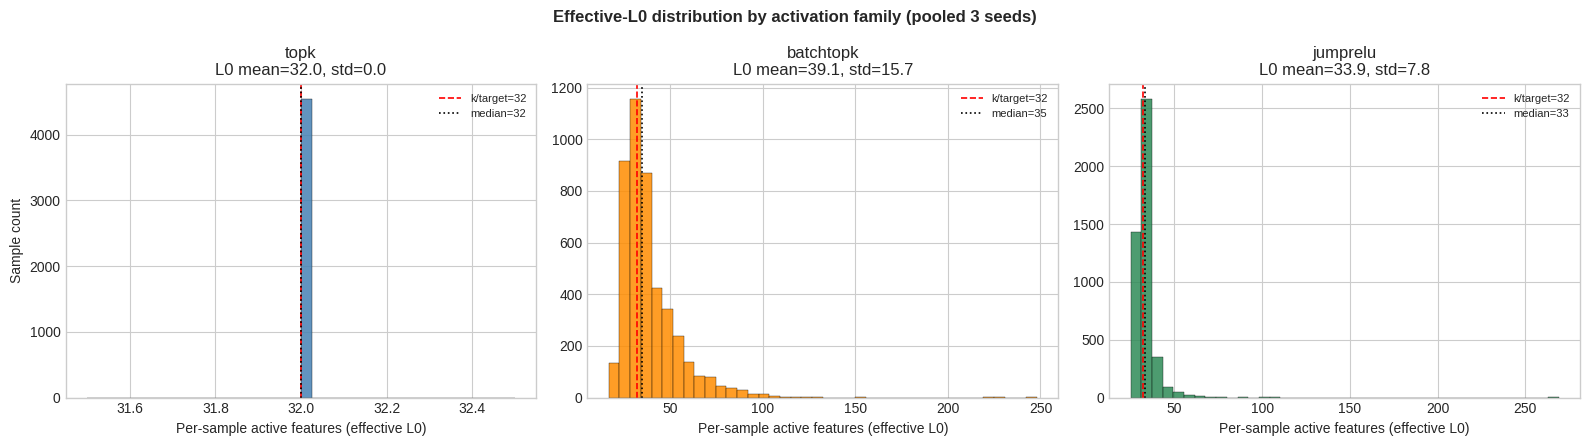

Saved: /home/marcantoniolopez/Documenti/github/xai-project-5/results/figures/ablation/a4_effective_l0_distribution.png


In [8]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=False)
colors = {'topk': 'steelblue', 'batchtopk': 'darkorange', 'jumprelu': 'seagreen'}
for ax, v in zip(axes, ('topk', 'batchtopk', 'jumprelu')):
    all_l0 = np.concatenate([per_variant_metrics[v][s]['l0_per_sample'] for s in ABLATION_SEEDS])
    ax.hist(all_l0, bins=40, color=colors[v], alpha=0.85, edgecolor='black', linewidth=0.3)
    ax.axvline(K, color='red', linestyle='--', linewidth=1.2, label=f'k/target={K}')
    ax.axvline(np.median(all_l0), color='black', linestyle=':', linewidth=1.2,
               label=f'median={np.median(all_l0):.0f}')
    ax.set_title(f'{v}\nL0 mean={all_l0.mean():.1f}, std={all_l0.std():.1f}')
    ax.set_xlabel('Per-sample active features (effective L0)')
    ax.legend(fontsize=8)
axes[0].set_ylabel('Sample count')
fig.suptitle('Effective-L0 distribution by activation family (pooled 3 seeds)', fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'a4_effective_l0_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIGURES_DIR / "a4_effective_l0_distribution.png"}')

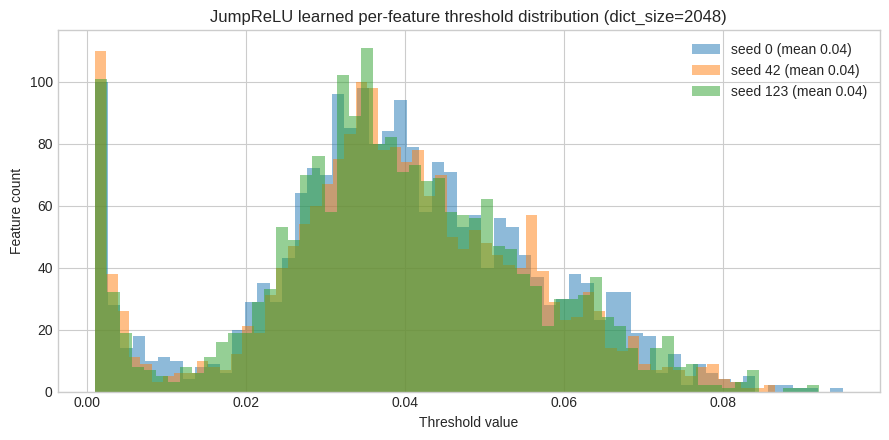

Saved: /home/marcantoniolopez/Documenti/github/xai-project-5/results/figures/ablation/a4_jumprelu_threshold_hist.png


In [9]:
# JumpReLU learned-threshold distribution (the per-feature gate that drives adaptive sparsity).
fig, ax = plt.subplots(figsize=(9, 4.5))
for seed in ABLATION_SEEDS:
    m = load_model('jumprelu', seed)
    thr = m.threshold.detach().cpu().numpy()
    ax.hist(thr, bins=60, alpha=0.5, label=f'seed {seed} (mean {thr.mean():.2f})')
    del m
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()
ax.set_title('JumpReLU learned per-feature threshold distribution (dict_size=2048)')
ax.set_xlabel('Threshold value')
ax.set_ylabel('Feature count')
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'a4_jumprelu_threshold_hist.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIGURES_DIR / "a4_jumprelu_threshold_hist.png"}')

## 5. Within-family stability (renormalized active-set Jaccard)

We cannot use `SAEManager.compute_stability` (hardcodes `AutoEncoderTopK`), nor
compare raw active-INDEX sets across families (different effective L0). Hard rule #1:
**Jaccard within-group only, at a common active-set size.**

Protocol (per family, over its 3 seeds):
1. Build per-sample top-n active-INDEX sets with `n=N_ACTIVE=20` so the Jaccard
   denominator is comparable across families.
2. Average Jaccard over samples, then strict-upper-triangle mean/std across the
   3 seed pairs — the same statistic `compute_stability` returns.

The **signal-to-null ratio** = `mean_jaccard / (N_ACTIVE / dict_size)` measures
how much observed overlap exceeds the random-overlap floor (20 of 2048).

In [10]:
N_ACTIVE = 20   # common active-set size for fair cross-family Jaccard (hard rule #1)

def topn_active_indices(variant, model, x, n):
    """Per-sample set of the n highest-|activation| feature indices, as a list[set[int]]."""
    sets = []
    with torch.no_grad():
        for i in range(0, len(x), CHUNK):
            xb = x[i:i + CHUNK].to(DEVICE)
            if variant == 'topk':
                sparse = model.encode(xb, use_threshold=False)
            elif variant == 'batchtopk':
                sparse = model.encode(xb, use_threshold=True)
            elif variant == 'jumprelu':
                sparse = model.encode(xb)
            # top-n by magnitude (clamp to feature count; keep only nonzero).
            vals, idx = sparse.abs().topk(min(n, sparse.shape[1]), dim=1, sorted=False)
            for r in range(idx.shape[0]):
                row_idx = idx[r].tolist()
                row_vals = vals[r]
                keep = [row_idx[j] for j in range(len(row_idx)) if row_vals[j].item() > 0]
                sets.append(set(keep))
    return sets

def stability_from_active_sets(active_sets, n_seeds, n_samples):
    """Standalone Jaccard loop (mirrors SAEManager.compute_stability math)."""
    jm = torch.zeros(n_seeds, n_seeds)
    for i in range(n_seeds):
        for j in range(i, n_seeds):
            if i == j:
                jm[i, j] = 1.0
                continue
            jac = []
            for s in range(n_samples):
                a, b = active_sets[i][s], active_sets[j][s]
                union = len(a | b)
                jac.append(len(a & b) / union if union > 0 else 0.0)
            mean_j = sum(jac) / len(jac)
            jm[i, j] = mean_j
            jm[j, i] = mean_j
    mask = torch.triu(torch.ones(n_seeds, n_seeds), diagonal=1).bool()
    upper = jm[mask]
    return {
        'jaccard_matrix': jm,
        'mean_jaccard': upper.mean().item() if upper.numel() else 0.0,
        'std_jaccard': upper.std(correction=0).item() if upper.numel() > 1 else 0.0,
    }

within_stability = {}
n_samples = test_emb.shape[0]
for v in ('topk', 'batchtopk', 'jumprelu'):
    per_seed_sets = []
    for seed in ABLATION_SEEDS:
        m = load_model(v, seed)
        per_seed_sets.append(topn_active_indices(v, m, test_emb, N_ACTIVE))
        del m
        if DEVICE == 'cuda':
            torch.cuda.empty_cache()
    res = stability_from_active_sets(per_seed_sets, len(ABLATION_SEEDS), n_samples)
    random_floor = N_ACTIVE / DICT_SIZE
    res['signal_to_null'] = res['mean_jaccard'] / random_floor if random_floor > 0 else float('inf')
    res['random_floor'] = random_floor
    within_stability[v] = res
    print(f"{v:10s}: mean Jaccard (n={N_ACTIVE}, {len(ABLATION_SEEDS)} seeds) = "
          f"{res['mean_jaccard']:.5f}  (std {res['std_jaccard']:.5f}, "
          f"signal/null = {res['signal_to_null']:.2f}x over floor {random_floor:.5f})")

topk      : mean Jaccard (n=20, 3 seeds) = 0.00379  (std 0.00038, signal/null = 0.39x over floor 0.00977)


batchtopk : mean Jaccard (n=20, 3 seeds) = 0.00368  (std 0.00144, signal/null = 0.38x over floor 0.00977)


jumprelu  : mean Jaccard (n=20, 3 seeds) = 0.00813  (std 0.00587, signal/null = 0.83x over floor 0.00977)


## 6. Consensus reappearance rate (index-agnostic, per family)

Following the a0 approach: pool the 3 seeds' **live decoder rows** for one
family, cosine-cluster at `tau=0.90`, and count clusters that span `>=2/3`
seeds. This is a robustness metric that does NOT depend on the shared index
space (two seeds never agree on feature indices, but they may rediscover the
same concept *direction*).

In [11]:
def consensus_reappearance(variant, tau=0.90, min_seeds=2):
    """Pool live decoder rows across a family's seeds, cluster by cosine, count
    clusters spanning >= min_seeds seeds. Returns summary dict."""
    rows, seed_tags = [], []
    dead_threshold = 1e-8
    for si, seed in enumerate(ABLATION_SEEDS):
        m = load_model(variant, seed)
        W = get_decoder_rows(variant, m)                 # (dict_size, act_dim)
        norms = W.norm(dim=1)
        live = (norms >= dead_threshold).nonzero(as_tuple=True)[0]
        rows.append(F.normalize(W[live], dim=1))
        seed_tags.append(torch.full((len(live),), si, dtype=torch.long))
        del m
        if DEVICE == 'cuda':
            torch.cuda.empty_cache()
    R = torch.cat(rows, dim=0)                           # (M, act_dim)
    tags = torch.cat(seed_tags, dim=0)                  # (M,)
    M = R.shape[0]

    # Greedy cosine clustering at tau (chunked to bound memory).
    assigned = torch.full((M,), -1, dtype=torch.long)
    cluster_id = 0
    cluster_seed_sets = []
    for i in range(M):
        if assigned[i] >= 0:
            continue
        sims = []
        for j0 in range(0, M, 2048):
            sims.append(R[i:i+1] @ R[j0:j0+2048].T)
        sim = torch.cat(sims, dim=1).squeeze(0)         # (M,)
        members = (sim >= tau).nonzero(as_tuple=True)[0]
        assigned[members] = cluster_id
        cluster_seed_sets.append(set(tags[m].item() for m in members))
        cluster_id += 1

    n_clusters = cluster_id
    n_consensus = sum(1 for s in cluster_seed_sets if len(s) >= min_seeds)
    n_all3 = sum(1 for s in cluster_seed_sets if len(s) >= 3)
    return {
        'n_pooled_rows': int(M),
        'n_clusters': n_clusters,
        'n_consensus': n_consensus,
        'consensus_rate': n_consensus / n_clusters if n_clusters else 0.0,
        'n_spanning_all3': n_all3,
        'spanning_all3_rate': n_all3 / n_clusters if n_clusters else 0.0,
    }

consensus = {v: consensus_reappearance(v, tau=0.90, min_seeds=2) for v in ('topk', 'batchtopk', 'jumprelu')}
print(f"{'variant':10s} {'pooled':>7s} {'clusters':>8s} {'consensus':>9s} {'rate':>7s} {'all3':>5s} {'all3%':>6s}")
for v in ('topk', 'batchtopk', 'jumprelu'):
    c = consensus[v]
    print(f"{v:10s} {c['n_pooled_rows']:>7d} {c['n_clusters']:>8d} {c['n_consensus']:>9d} "
          f"{c['consensus_rate']:>7.3f} {c['n_spanning_all3']:>5d} {c['spanning_all3_rate']*100:>5.1f}%")

variant     pooled clusters consensus    rate  all3  all3%
topk          6144     6144         0   0.000     0   0.0%
batchtopk     6144     6144         0   0.000     0   0.0%
jumprelu      6144     6144         0   0.000     0   0.0%


## 7. Cross-activation consensus (family-invariant concepts)

The headline novelty claim: which concept directions are **family-invariant**?
Pool all **9 models** (3 families x 3 seeds) live decoder rows, cosine-cluster
at `tau=0.90`, count clusters spanning `>=2` **activation families**. A high
rate means the same concepts are rediscovered regardless of the sparsity
mechanism — a strong robustness statement.

In [12]:
def cross_activation_consensus(tau=0.90, min_families=2):
    family_idx = {'topk': 0, 'batchtopk': 1, 'jumprelu': 2}
    rows, fam_tags = [], []
    dead_threshold = 1e-8
    for v in ('topk', 'batchtopk', 'jumprelu'):
        fi = family_idx[v]
        for seed in ABLATION_SEEDS:
            m = load_model(v, seed)
            W = get_decoder_rows(v, m)
            live = (W.norm(dim=1) >= dead_threshold).nonzero(as_tuple=True)[0]
            rows.append(F.normalize(W[live], dim=1))
            fam_tags.append(torch.full((len(live),), fi, dtype=torch.long))
            del m
            if DEVICE == 'cuda':
                torch.cuda.empty_cache()
    R = torch.cat(rows, dim=0)
    tags = torch.cat(fam_tags, dim=0)
    M = R.shape[0]

    assigned = torch.full((M,), -1, dtype=torch.long)
    cluster_id = 0
    cluster_fam_sets = []
    for i in range(M):
        if assigned[i] >= 0:
            continue
        sims = []
        for j0 in range(0, M, 2048):
            sims.append(R[i:i+1] @ R[j0:j0+2048].T)
        sim = torch.cat(sims, dim=1).squeeze(0)
        members = (sim >= tau).nonzero(as_tuple=True)[0]
        assigned[members] = cluster_id
        cluster_fam_sets.append(set(tags[m].item() for m in members))
        cluster_id += 1

    n_clusters = cluster_id
    n_span2 = sum(1 for s in cluster_fam_sets if len(s) >= min_families)
    n_span3 = sum(1 for s in cluster_fam_sets if len(s) >= 3)
    return {
        'n_pooled_rows': int(M),
        'n_clusters': n_clusters,
        'n_spanning_2families': n_span2,
        'spanning_2families_rate': n_span2 / n_clusters if n_clusters else 0.0,
        'n_spanning_3families': n_span3,
        'spanning_3families_rate': n_span3 / n_clusters if n_clusters else 0.0,
    }

cross = cross_activation_consensus(tau=0.90, min_families=2)
print('Cross-activation consensus (9 models, tau=0.90):')
for k in ('n_pooled_rows', 'n_clusters', 'n_spanning_2families',
          'spanning_2families_rate', 'n_spanning_3families', 'spanning_3families_rate'):
    val = cross[k]
    if isinstance(val, float):
        print(f'  {k:30s}: {val:.4f}')
    else:
        print(f'  {k:30s}: {val}')

Cross-activation consensus (9 models, tau=0.90):
  n_pooled_rows                 : 18432
  n_clusters                    : 17923
  n_spanning_2families          : 509
  spanning_2families_rate       : 0.0284
  n_spanning_3families          : 0
  spanning_3families_rate       : 0.0000


## 8. Concept naming (primary seed 42) — decoder<->vocab cosine

Per family, name the primary-seed live features via cosine to the vocabulary
embeddings (standalone reimplementation of `name_concepts`: decoder-norm dead
test at `1e-8`, F.normalize, top_n candidates). Naming is gap-corrected to match
the baseline.

In [13]:
def name_decoder_rows(W_dec, vocab_emb, vocab_labels, top_n=3, dead_threshold=1e-8,
                      modality_gap=None):
    """Standalone name_concepts math (mirrors sa_module.SAEManager.name_concepts).
    If modality_gap is given, W_dec is shifted by -modality_gap before cosine
    (Solution 1) so the bake-off naming is gap-corrected like the baseline."""
    if modality_gap is not None:
        W_dec = W_dec - modality_gap.unsqueeze(0).to(W_dec.device)
    norms = W_dec.norm(dim=1)
    dead_mask = norms < dead_threshold
    W_norm = F.normalize(W_dec, dim=1)
    W_norm[dead_mask] = 0.0
    V_norm = F.normalize(vocab_emb, dim=1)
    sims = W_norm @ V_norm.T            # (dict_size, V)
    names = {}
    for f in range(W_dec.shape[0]):
        if dead_mask[f]:
            names[f] = {'name': 'DEAD_FEATURE', 'score': 0.0, 'candidates': [], 'is_dead': True}
            continue
        tk = sims[f].topk(top_n)
        cands = [{'label': vocab_labels[i.item()], 'score': float(v)} for v, i in zip(tk.values, tk.indices)]
        names[f] = {'name': cands[0]['label'], 'score': cands[0]['score'], 'candidates': cands, 'is_dead': False}
    return names

# Modality gap (Solution 1): visual_centroid - text_centroid.
modality_gap = train_emb.mean(dim=0) - vocab_emb.mean(dim=0)

naming = {}
for v in ('topk', 'batchtopk', 'jumprelu'):
    m = load_model(v, PRIMARY_SEED)
    W = get_decoder_rows(v, m)
    names = name_decoder_rows(W, vocab_emb, vocab_labels, top_n=3, modality_gap=modality_gap)
    live_scores = [info['score'] for info in names.values() if not info['is_dead']]
    naming[v] = {
        'n_live': len(live_scores),
        'mean_score': float(np.mean(live_scores)) if live_scores else 0.0,
        'max_score': float(np.max(live_scores)) if live_scores else 0.0,
        'names': names,
    }
    del m
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()
    print(f"{v:10s}: {naming[v]['n_live']} live features, naming cosine "
          f"mean={naming[v]['mean_score']:.4f} max={naming[v]['max_score']:.4f}")
    # Top-5 named concepts.
    top5 = sorted(((info['name'], info['score']) for info in names.values() if not info['is_dead']),
                  key=lambda x: x[1], reverse=True)[:5]
    for nm, sc in top5:
        print(f'    {sc:.4f}  {nm}')
    print()

topk      : 2048 live features, naming cosine mean=0.4024 max=0.5517
    0.5517  ligamentum flavum
    0.5286  ligamentum flavum
    0.5282  endocavitary linear transducer
    0.5260  lumbar segment of spinal cord
    0.5246  lumbar segment of spinal cord

batchtopk : 2048 live features, naming cosine mean=0.3992 max=0.5380
    0.5380  sacral segment of spinal cord
    0.5341  sacral segment of spinal epidural space
    0.5073  endotracheal tube
    0.5054  fasciculus cuneatus of spinal cord
    0.5015  moderate central spinal stenosis



jumprelu  : 2048 live features, naming cosine mean=0.3881 max=0.5942
    0.5942  curved sheath
    0.5532  comet sign
    0.5441  lumbosacral spine
    0.5364  enlarged liver
    0.5356  anterior ramus of spinal nerve



## 9. Figures

### Figure 1 — Activation-comparison bar across the 3 families
Reconstruction cosine, dead%, within-family signal-to-null Jaccard, consensus
reappearance rate.

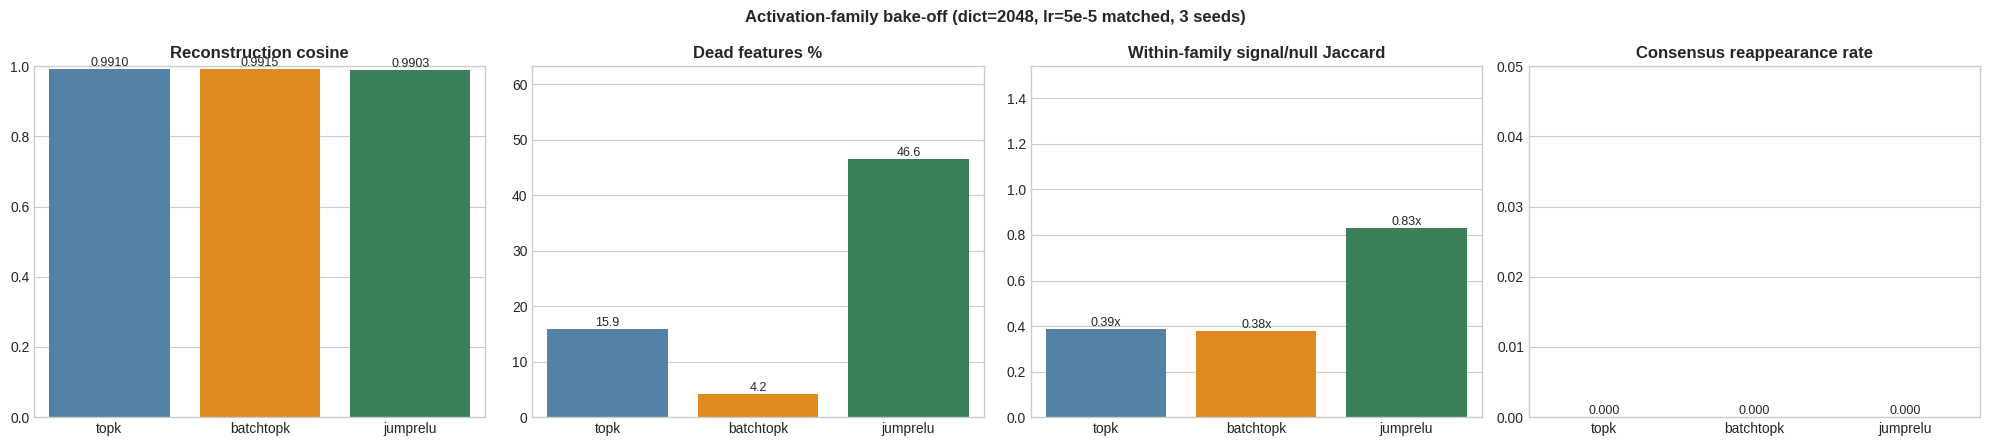

Saved: /home/marcantoniolopez/Documenti/github/xai-project-5/results/figures/ablation/a4_activation_comparison.png


In [14]:
import seaborn as sns

variants = ['topk', 'batchtopk', 'jumprelu']
recon_mean = [np.mean([per_variant_metrics[v][s]['recon_cos'] for s in ABLATION_SEEDS]) for v in variants]
dead_mean = [np.mean([per_variant_metrics[v][s]['dead_pct'] for s in ABLATION_SEEDS]) for v in variants]
s2n = [within_stability[v]['signal_to_null'] for v in variants]
cons_rate = [consensus[v]['consensus_rate'] for v in variants]

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
pal = {'topk': 'steelblue', 'batchtopk': 'darkorange', 'jumprelu': 'seagreen'}

def bar(ax, vals, title, fmt='{:.3f}', ylim=None):
    sns.barplot(x=variants, y=vals, ax=ax,
                palette=[pal[v] for v in variants], hue=variants, legend=False)
    ax.set_title(title, fontweight='bold')
    for i, val in enumerate(vals):
        ax.text(i, val, fmt.format(val), ha='center', va='bottom', fontsize=9)
    if ylim:
        ax.set_ylim(ylim)

bar(axes[0], recon_mean, 'Reconstruction cosine', '{:.4f}', (0, 1))
bar(axes[1], dead_mean, 'Dead features %', '{:.1f}', (0, max(dead_mean) * 1.25 + 5))
bar(axes[2], s2n, 'Within-family signal/null Jaccard', '{:.2f}x', (0, max(s2n) * 1.25 + 0.5))
bar(axes[3], cons_rate, 'Consensus reappearance rate', '{:.3f}', (0, max(cons_rate) * 1.25 + 0.05))
fig.suptitle('Activation-family bake-off (dict=2048, lr=5e-5 matched, 3 seeds)', fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'a4_activation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIGURES_DIR / "a4_activation_comparison.png"}')

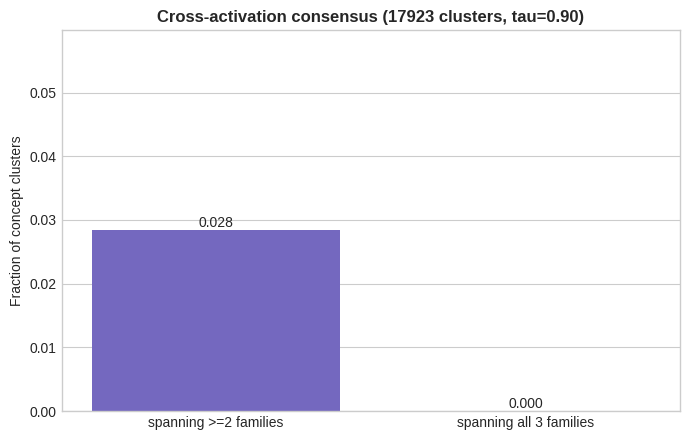

Saved: /home/marcantoniolopez/Documenti/github/xai-project-5/results/figures/ablation/a4_cross_activation_consensus.png


In [15]:
# Figure 3 — cross-activation consensus bar.
fig, ax = plt.subplots(figsize=(7, 4.5))
rates = [cross['spanning_2families_rate'], cross['spanning_3families_rate']]
labels = ['spanning >=2 families', 'spanning all 3 families']
sns.barplot(x=labels, y=rates, ax=ax, palette=['#6a5acd', '#2e8b57'], hue=labels, legend=False)
for i, r in enumerate(rates):
    ax.text(i, r, f'{r:.3f}', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Fraction of concept clusters')
ax.set_title(f'Cross-activation consensus ({cross["n_clusters"]} clusters, tau=0.90)', fontweight='bold')
ax.set_ylim(0, max(rates) * 1.4 + 0.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'a4_cross_activation_consensus.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIGURES_DIR / "a4_cross_activation_consensus.png"}')

## 10. Persist results

Write `results/ablation/a4_activation.json` with all per-variant, cross-variant,
and cross-activation numbers.

In [16]:
def _clean(d):
    """Strip numpy arrays / tensors so the payload is JSON-serializable."""
    out = {}
    for k, v in d.items():
        if isinstance(v, np.ndarray):
            continue  # skip per-sample arrays
        if isinstance(v, torch.Tensor):
            out[k] = v.tolist()
        elif isinstance(v, np.generic):
            out[k] = v.item()
        else:
            out[k] = v
    return out

payload = {
    'ablation': '04_activation_bakeoff',
    'params': {
        'dict_size': DICT_SIZE,
        'activation_dim': ACTIVATION_DIM,
        'lr': LR,
        'steps': N_STEPS,
        'batch_size': BATCH_SIZE,
        'seeds': list(ABLATION_SEEDS),
        'primary_seed': PRIMARY_SEED,
        'k': K,
        'target_l0': TARGET_L0,
        'auxk_alpha': AUXK_ALPHA,
        'bandwidth': BANDWIDTH,
        'sparsity_penalty': SPARSITY_PENALTY,
        'sparsity_warmup_steps': SPARSITY_WARMUP_STEPS,
        'normalize_activations': False,
        'n_active_jaccard': N_ACTIVE,
        'n_test_samples': int(test_emb.shape[0]),
        'naming': 'gap-corrected (Solution 1: W_dec -= visual_centroid - text_centroid)',
    },
    'baseline_reference': {
        'recon_cos': 0.988, 'dead_pct': 44.0, 'mean_jaccard_index': 0.0038,
        'naming_mean': 0.3949, 'naming_max': 0.5457, 'dict_size': 4096,
        'naming_note': 'gap-corrected (Solution 1), seed 42',
    },
    'per_variant_metrics': {v: {int(s): _clean(per_variant_metrics[v][s]) for s in ABLATION_SEEDS}
                            for v in variants},
    'within_family_stability': {v: _clean(within_stability[v]) for v in variants},
    'consensus_reappearance': {v: _clean(consensus[v]) for v in variants},
    'cross_activation_consensus': _clean(cross),
    'naming_summary': {v: {k2: naming[v][k2] for k2 in ('n_live', 'mean_score', 'max_score')}
                       for v in variants},
}

results_path = RESULTS_DIR / 'a4_activation.json'
with open(results_path, 'w') as f:
    json.dump(payload, f, indent=2)
print(f'Saved: {results_path}  ({results_path.stat().st_size / 1024:.1f} KB)')

print('\n=== Headline summary ===')
print(f"{'variant':10s} {'recon':>7s} {'dead%':>6s} {'s/null':>7s} {'consensus':>9s} {'name_max':>8s}")
for v in variants:
    print(f"{v:10s} "
          f"{np.mean([per_variant_metrics[v][s]['recon_cos'] for s in ABLATION_SEEDS]):>7.4f} "
          f"{np.mean([per_variant_metrics[v][s]['dead_pct'] for s in ABLATION_SEEDS]):>6.1f} "
          f"{within_stability[v]['signal_to_null']:>7.2f} "
          f"{consensus[v]['consensus_rate']:>9.3f} "
          f"{naming[v]['max_score']:>8.4f}")
print(f"\nCross-activation: {cross['spanning_2families_rate']*100:.1f}% of {cross['n_clusters']} clusters "
      f"span >=2 families; {cross['spanning_3families_rate']*100:.1f}% span all 3.")

Saved: /home/marcantoniolopez/Documenti/github/xai-project-5/results/ablation/a4_activation.json  (6.1 KB)

=== Headline summary ===
variant      recon  dead%  s/null consensus name_max
topk        0.9910   15.9    0.39     0.000   0.5517
batchtopk   0.9915    4.2    0.38     0.000   0.5380
jumprelu    0.9903   46.6    0.83     0.000   0.5942

Cross-activation: 2.8% of 17923 clusters span >=2 families; 0.0% span all 3.


## 11. Notes & caveats

**Pre-registered hypothesis check.** If BatchTopK/JumpReLU do not beat TopK on
consensus-rate and dead%, the lr-matching trade-off (each variant's tuned default
sacrificed for a valid comparison) is a likely contributor.

**lr-matching trade-off.** TopK/BatchTopK auto-scale to ~2.8e-4 at dict_size=2048;
JumpReLU defaults to 7e-5. We pin all three at 5e-5 to kill the ~8x lr confound —
conservative, possibly under-training TopK/BatchTopK. Re-check at family-tuned lr
in a follow-up.

**Index-Jaccard is within-family only.** Cross-family index-Jaccard is meaningless
(different indices, different effective L0). We report renormalized within-family
Jaccard (n=20), signal-to-null ratio, consensus-reappearance, and cross-activation
consensus — all index/size-agnostic.

**Dead% definition.** Fraction of features never nonzero on the test set
(activation-based). Never read the trainers' `dead_features` counter (its
`10_000_000`-step threshold is meaningless at 12000 steps).